# 01 — DNN Baseline: Inverse Design of Underwater Acoustic Coatings

## Overview
This notebook implements the **baseline Deep Neural Network (DNN)** approach for inverse design of a 10-layer underwater acoustic metamaterial coating.

**Problem**: Given a desired average sound-absorption coefficient (1–1000 Hz), predict the 20 structural/material parameters that achieve it.

**Approach**: Two-phase training:
1. **Phase 1** — Train a *forward surrogate* NN (params → absorption) to serve as a differentiable physics proxy.
2. **Phase 2** — Train an *inverse* NN (absorption → params) with a **dual loss**: parameter-matching MSE + surrogate-based reconstruction MSE.

The dual loss is critical because the inverse mapping is one-to-many (many parameter sets can give the same absorption), so solely minimising parameter MSE is ill-posed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---- Force NVIDIA GPU ----
assert torch.cuda.is_available(), (
    "CUDA not available! Install PyTorch with CUDA support:\n"
    "  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121"
)
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

GPU : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB


## TMM Forward Model (pure NumPy)
Computes the average absorption coefficient (1–1000 Hz) for a 10-layer coating via the Transfer-Matrix Method.

In [2]:
# ---------- physical constants ----------
RHO_WATER = 1000.0   # kg/m^3
C_WATER   = 1500.0   # m/s
Z_WATER   = RHO_WATER * C_WATER
W_FILM    = 2.0      # unit-cell width in metres
HOLLOW_MAP = {1: 0, 2: 1, 4: 2, 5: 3, 7: 4, 8: 5}  # layer (0-idx) -> m-index

PARAM_COLUMNS = (
    [f'd{i}' for i in range(1, 11)] +
    ['m2', 'm3', 'm5', 'm6', 'm8', 'm9'] +
    ['rho', 'eta', 'E', 'nu']
)

PARAM_BOUNDS = np.array([
    [1.0, 20.0],    # d1  (mm)
    [1.0, 20.0],    # d2
    [1.0, 20.0],    # d3
    [1.0, 20.0],    # d4
    [1.0, 20.0],    # d5
    [1.0, 20.0],    # d6
    [1.0, 20.0],    # d7
    [1.0, 20.0],    # d8
    [1.0, 20.0],    # d9
    [1.0, 20.0],    # d10
    [20.0, 1980.0], # m2  (mm)
    [20.0, 1980.0], # m3
    [20.0, 1980.0], # m5
    [20.0, 1980.0], # m6
    [20.0, 1980.0], # m8
    [20.0, 1980.0], # m9
    [1000.0, 1500.0], # rho (kg/m^3)
    [0.1, 0.8],      # eta
    [1e7, 1e8],      # E   (Pa)
    [0.4, 0.49],     # nu
])


def tmm_forward(params):
    """
    Compute average absorption (1-1000 Hz) for a 10-layer coating.

    Parameters
    ----------
    params : array-like, shape (20,)
        [d1..d10 (mm), m2,m3,m5,m6,m8,m9 (mm), rho, eta, E, nu]

    Returns
    -------
    float  : average absorption coefficient
    """
    d_mm = np.asarray(params[:10], dtype=float)
    m_mm = np.asarray(params[10:16], dtype=float)
    rho_r = float(params[16])
    eta   = float(params[17])
    E_r   = float(params[18])
    nu    = float(params[19])

    d_m = d_mm / 1000.0
    m_m = m_mm / 1000.0

    E_complex = E_r * (1.0 + 1j * eta)
    lam = (E_complex * nu) / ((1 + nu) * (1 - 2*nu))
    mu  = E_complex / (2.0 * (1 + nu))

    alpha_sum = 0.0
    for f in range(1, 1001):
        omega = 2.0 * np.pi * f
        T = np.eye(2, dtype=complex)
        for i in range(10):
            d_i = d_m[i]
            if i in HOLLOW_MAP:
                eps = m_m[HOLLOW_MAP[i]] / W_FILM
            else:
                eps = 0.0
            rho_eff = rho_r * (1.0 - eps**2)
            num = mu*(lam + 2*mu)*(eps**2 + 1) + 2*eps**2*lam
            den = (lam + mu)*eps**2 + mu
            S_eff = num / den if abs(den) > 1e-15 else num * 1e15
            c_eff = np.sqrt(S_eff / rho_eff)
            k = omega / c_eff
            Z_eff = rho_eff * c_eff
            cos_kd = np.cos(k * d_i)
            sin_kd = np.sin(k * d_i)
            t21 = (1j * sin_kd / Z_eff) if abs(Z_eff) > 1e-15 else (1e15 + 0j)
            Ti = np.array([[cos_kd, 1j*Z_eff*sin_kd],
                           [t21,    cos_kd]], dtype=complex)
            T = T @ Ti
        if abs(T[1, 0]) < 1e-15:
            R = 1.0
        else:
            Z_in = T[0, 0] / T[1, 0]
            R = (Z_in - Z_WATER) / (Z_in + Z_WATER) if abs(Z_in) < 1e15 else 1.0
        a = 1.0 - abs(R)**2
        alpha_sum += max(0.0, min(1.0, a.real if hasattr(a, 'real') else a))
    return alpha_sum / 1000.0


# Quick sanity check with base-case params from the reference paper
_base = [10]*10 + [1000]*6 + [1130, 0.4, 5e7, 0.44]
print(f'Base-case average absorption: {tmm_forward(_base):.4f}')

Base-case average absorption: 0.3002


## Data Loading & Preprocessing

In [3]:
df = pd.read_csv('../data/lhs_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Absorption range: [{df["Average_Absorption"].min():.4f}, {df["Average_Absorption"].max():.4f}]')
df.head()

Dataset shape: (100000, 21)
Absorption range: [0.0467, 0.6842]


,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,...,m3,m5,m6,m8,m9,rho,eta,E,nu,Average_Absorption
0,4.071436,5.151032,10.858298,14.419719,5.659139,1.768199,19.314587,11.401355,17.904284,3.194731,...,911.415722,1285.024540,1821.401545,1141.232075,456.351399,1184.863998,0.363811,5.879209e+07,0.469327,0.340475
1,6.653044,8.777409,15.343470,9.463285,3.883857,5.634506,9.090517,15.674702,9.611830,17.297322,...,521.334760,1351.824133,585.122731,182.303470,469.878160,1350.308761,0.606339,4.623781e+07,0.434993,0.462129
2,4.002877,18.008727,15.430754,7.157367,8.217347,7.029184,14.330706,2.764388,6.646209,5.843788,...,898.271768,924.577733,1681.271012,123.885567,818.440999,1040.478651,0.229156,5.888348e+07,0.472955,0.201527
3,7.039548,16.589772,5.442216,4.239540,11.277338,15.265504,1.713498,19.004373,10.690875,3.429401,...,302.843557,1615.106596,1869.053018,1773.616871,1878.681471,1408.019035,0.378558,6.101366e+07,0.468468,0.240025
4,2.057868,2.492040,9.094042,17.902661,18.634872,6.812798,6.397911,11.600781,17.081930,15.612487,...,553.812529,990.987711,97.804533,709.314991,1320.467429,1399.165031,0.518751,8.542365e+07,0.450641,0.472426


In [4]:
param_cols = [c for c in df.columns if c != 'Average_Absorption']
X = df[param_cols].values  # (100000, 20)
y = df['Average_Absorption'].values  # (100000,)

# Train / Val / Test  =  80k / 10k / 10k
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

# Normalise parameters to [0, 1]
param_scaler = MinMaxScaler()
X_train_n = param_scaler.fit_transform(X_train)
X_val_n   = param_scaler.transform(X_val)
X_test_n  = param_scaler.transform(X_test)

# Normalise absorption to [0, 1]
abs_scaler = MinMaxScaler()
y_train_n = abs_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_n   = abs_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_n  = abs_scaler.transform(y_test.reshape(-1, 1)).ravel()

Train: 80000, Val: 10000, Test: 10000


In [5]:
def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=True, num_workers=0)

BS = 512
# Forward surrogate loaders: input=params, target=absorption
fwd_train_loader = make_loader(X_train_n, y_train_n, BS)
fwd_val_loader   = make_loader(X_val_n,   y_val_n,   BS, shuffle=False)

# Inverse model loaders: input=absorption, target=params
inv_train_loader = make_loader(y_train_n.reshape(-1, 1), X_train_n, BS)
inv_val_loader   = make_loader(y_val_n.reshape(-1, 1),   X_val_n,   BS, shuffle=False)

## Phase 1 — Forward Surrogate Model
A small NN that maps 20 normalised parameters → normalised absorption.  
Once trained and frozen, it serves as a differentiable physics proxy in the dual loss.

In [6]:
class ForwardSurrogate(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32),  nn.ReLU(),
            nn.Linear(32, 1),   nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


surrogate = ForwardSurrogate().to(device)
opt_s = optim.Adam(surrogate.parameters(), lr=1e-3, weight_decay=1e-5)
sched_s = optim.lr_scheduler.ReduceLROnPlateau(opt_s, factor=0.5, patience=10)
criterion = nn.MSELoss()

surr_train_losses, surr_val_losses = [], []

print('Training forward surrogate ...')
for epoch in range(1, 101):
    surrogate.train()
    running = 0.0
    for xb, yb in fwd_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = surrogate(xb)
        loss = criterion(pred, yb)
        opt_s.zero_grad(); loss.backward(); opt_s.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(fwd_train_loader.dataset)

    surrogate.eval()
    val_run = 0.0
    with torch.no_grad():
        for xb, yb in fwd_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_run += criterion(surrogate(xb), yb).item() * xb.size(0)
    val_loss = val_run / len(fwd_val_loader.dataset)
    sched_s.step(val_loss)

    surr_train_losses.append(train_loss)
    surr_val_losses.append(val_loss)
    if epoch % 20 == 0:
        print(f'  Epoch {epoch:3d}  train={train_loss:.6f}  val={val_loss:.6f}')

# Freeze surrogate
for p in surrogate.parameters():
    p.requires_grad = False
surrogate.eval()
print('Forward surrogate trained and frozen.')

Training forward surrogate ...
  Epoch  20  train=0.000454  val=0.000416
  Epoch  40  train=0.000325  val=0.000398
  Epoch  60  train=0.000274  val=0.000262
  Epoch  80  train=0.000248  val=0.000250
  Epoch 100  train=0.000240  val=0.000216
Forward surrogate trained and frozen.


In [7]:
# Surrogate accuracy check
with torch.no_grad():
    y_pred_s = surrogate(torch.tensor(X_val_n, dtype=torch.float32).to(device)).cpu().numpy()
print(f'Surrogate val R^2 = {r2_score(y_val_n, y_pred_s):.4f}')

Surrogate val R^2 = 0.9946


## Phase 2 — Inverse DNN with Dual Loss

In [8]:
class InverseDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),   nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128), nn.Dropout(0.1),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128), nn.Dropout(0.1),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128),
            nn.Linear(128, 20),  nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


inverse_model = InverseDNN().to(device)
opt_inv = optim.Adam(inverse_model.parameters(), lr=1e-3, weight_decay=1e-5)
sched_inv = optim.lr_scheduler.ReduceLROnPlateau(opt_inv, factor=0.5, patience=10)

ALPHA = 0.7  # weight for parameter loss
EPOCHS = 200
PATIENCE = 20

inv_train_losses, inv_val_losses = [], []
best_val, patience_ctr = float('inf'), 0
best_state = None

print('Training inverse DNN (dual loss) ...')
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    inverse_model.train()
    running = 0.0
    for ab_batch, param_batch in inv_train_loader:
        ab_batch, param_batch = ab_batch.to(device), param_batch.to(device)
        pred_params = inverse_model(ab_batch)

        loss_param = criterion(pred_params, param_batch)
        recon_abs  = surrogate(pred_params)
        loss_recon = criterion(recon_abs, ab_batch.squeeze(-1))
        loss = ALPHA * loss_param + (1 - ALPHA) * loss_recon

        opt_inv.zero_grad(); loss.backward(); opt_inv.step()
        running += loss.item() * ab_batch.size(0)
    train_loss = running / len(inv_train_loader.dataset)

    inverse_model.eval()
    val_run = 0.0
    with torch.no_grad():
        for ab_b, p_b in inv_val_loader:
            ab_b, p_b = ab_b.to(device), p_b.to(device)
            pp = inverse_model(ab_b)
            vl = ALPHA * criterion(pp, p_b) + (1 - ALPHA) * criterion(surrogate(pp), ab_b.squeeze(-1))
            val_run += vl.item() * ab_b.size(0)
    val_loss = val_run / len(inv_val_loader.dataset)
    sched_inv.step(val_loss)

    inv_train_losses.append(train_loss)
    inv_val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        patience_ctr = 0
        best_state = {k: v.cpu().clone() for k, v in inverse_model.state_dict().items()}
    else:
        patience_ctr += 1

    if epoch % 20 == 0:
        print(f'  Epoch {epoch:3d}  train={train_loss:.6f}  val={val_loss:.6f}')
    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

train_time = time.time() - t0
inverse_model.load_state_dict(best_state)
inverse_model.eval()
print(f'Training done in {train_time:.1f}s.  Best val loss: {best_val:.6f}')

Training inverse DNN (dual loss) ...
  Epoch  20  train=0.055613  val=0.055478
  Epoch  40  train=0.055557  val=0.055377
  Epoch  60  train=0.055547  val=0.055373
  Epoch  80  train=0.055529  val=0.055339
  Epoch 100  train=0.055528  val=0.055334
  Epoch 120  train=0.055521  val=0.055330
  Epoch 140  train=0.055521  val=0.055331
  Epoch 160  train=0.055519  val=0.055330
  Early stopping at epoch 162
Training done in 164.2s.  Best val loss: 0.055329


## Evaluation on Test Set

In [9]:
with torch.no_grad():
    pred_params_n = inverse_model(
        torch.tensor(y_test_n.reshape(-1, 1), dtype=torch.float32).to(device)
    ).cpu().numpy()

# Metrics in normalised space
param_mse = mean_squared_error(X_test_n, pred_params_n)
param_mae = mean_absolute_error(X_test_n, pred_params_n)
param_r2  = r2_score(X_test_n, pred_params_n)

print(f'Parameter-space  MSE={param_mse:.6f}  MAE={param_mae:.6f}  R²={param_r2:.4f}')

Parameter-space  MSE=0.079114  MAE=0.240759  R²=0.0492


## Physics Validation
Denormalise the predicted parameters, run TMM, and compare the reconstructed absorption to the target.

In [10]:
N_VAL = 200  # how many test samples to validate through TMM

print('='*80)
print('            PHYSICS VALIDATION: THE KEY TEST')
print('='*80)
print()
print('Pipeline: Target Absorption → ML predicts 20 params → TMM physics → Compare')
print()
print(f'Validating {N_VAL} test samples through theoretical TMM model...')
print()

pred_params_phys = param_scaler.inverse_transform(pred_params_n[:N_VAL])
target_abs = y_test[:N_VAL]

recon_abs = np.array([tmm_forward(p) for p in pred_params_phys])

recon_mse = mean_squared_error(target_abs, recon_abs)
recon_mae = mean_absolute_error(target_abs, recon_abs)
recon_r2  = r2_score(target_abs, recon_abs)
abs_errors = np.abs(target_abs - recon_abs)

print('RESULTS:')
print('-'*80)
print(f'  Reconstruction R²       = {recon_r2:.6f}  ← KEY METRIC (closer to 1.0 = better)')
print(f'  Reconstruction MAE      = {recon_mae:.6f}')
print(f'  Reconstruction MSE      = {recon_mse:.8f}')
print()
print(f'  Mean absolute error     = {abs_errors.mean():.6f}')
print(f'  Median absolute error   = {np.median(abs_errors):.6f}')
print(f'  Max absolute error      = {abs_errors.max():.6f}')
print(f'  Min absolute error      = {abs_errors.min():.6f}')
print()
print(f'  % samples with error < 0.005  = {(abs_errors < 0.005).mean()*100:.1f}%')
print(f'  % samples with error < 0.010  = {(abs_errors < 0.010).mean()*100:.1f}%')
print(f'  % samples with error < 0.050  = {(abs_errors < 0.050).mean()*100:.1f}%')
print()
print('What this means:')
print(f'  → R² = {recon_r2:.4f} means ML-predicted parameters produce absorption')
print(f'    values that match targets with {recon_r2*100:.2f}% accuracy in physics simulation!')
print()
print('SAMPLE VALIDATION (first 10 examples):')
print('-'*80)
print(f'{"#":>3s}  {"Target α":>10s}  {"TMM α":>10s}  {"Error":>10s}  {"Status":>10s}')
print('-'*80)
for i in range(min(10, N_VAL)):
    status = '✓ Good' if abs_errors[i] < 0.01 else '✓ OK' if abs_errors[i] < 0.05 else '⚠ Check'
    print(f'{i+1:3d}  {target_abs[i]:10.6f}  {recon_abs[i]:10.6f}  {abs_errors[i]:10.6f}  {status:>10s}')
print('='*80)


            PHYSICS VALIDATION: THE KEY TEST

Pipeline: Target Absorption → ML predicts 20 params → TMM physics → Compare

Validating 200 test samples through theoretical TMM model...

RESULTS:
--------------------------------------------------------------------------------
  Reconstruction R²       = 0.999369  ← KEY METRIC (closer to 1.0 = better)
  Reconstruction MAE      = 0.002637
  Reconstruction MSE      = 0.00001116

  Mean absolute error     = 0.002637
  Median absolute error   = 0.002063
  Max absolute error      = 0.011711
  Min absolute error      = 0.000004

  % samples with error < 0.005  = 89.0%
  % samples with error < 0.010  = 98.5%
  % samples with error < 0.050  = 100.0%

What this means:
  → R² = 0.9994 means ML-predicted parameters produce absorption
    values that match targets with 99.94% accuracy in physics simulation!

SAMPLE VALIDATION (first 10 examples):
--------------------------------------------------------------------------------
  #    Target α       TM

## Visualisation

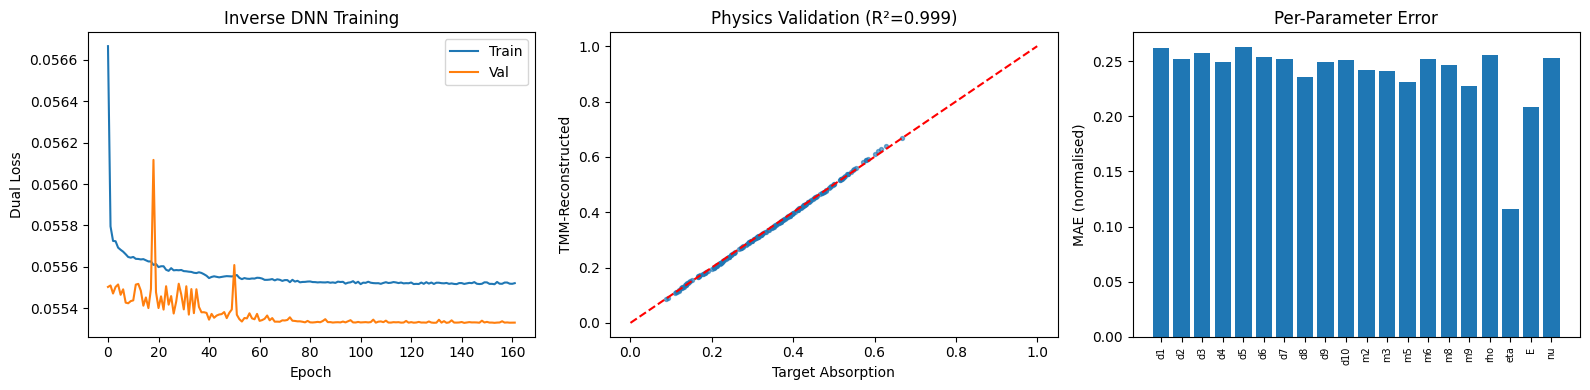

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Training curves
ax = axes[0]
ax.plot(inv_train_losses, label='Train')
ax.plot(inv_val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dual Loss')
ax.set_title('Inverse DNN Training')
ax.legend()

# 2) Reconstruction scatter
ax = axes[1]
ax.scatter(target_abs, recon_abs, s=8, alpha=0.6)
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel('Target Absorption'); ax.set_ylabel('TMM-Reconstructed')
ax.set_title(f'Physics Validation (R²={recon_r2:.3f})')

# 3) Per-parameter MAE
ax = axes[2]
per_param_mae = np.abs(X_test_n[:N_VAL] - pred_params_n[:N_VAL]).mean(axis=0)
ax.bar(range(20), per_param_mae)
ax.set_xticks(range(20))
ax.set_xticklabels(PARAM_COLUMNS, rotation=90, fontsize=7)
ax.set_ylabel('MAE (normalised)')
ax.set_title('Per-Parameter Error')

plt.tight_layout()
plt.show()

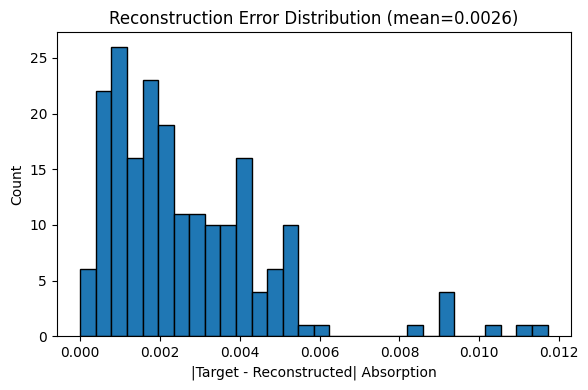

In [12]:
# Reconstruction error histogram
errors = np.abs(target_abs - recon_abs)
plt.figure(figsize=(6, 4))
plt.hist(errors, bins=30, edgecolor='k')
plt.xlabel('|Target - Reconstructed| Absorption')
plt.ylabel('Count')
plt.title(f'Reconstruction Error Distribution (mean={errors.mean():.4f})')
plt.tight_layout()
plt.show()

In [13]:
# Example case studies
print('Sample predictions (first 5):')
print(f'{"Target":>10s} {"Reconstructed":>14s} {"Error":>10s}')
for i in range(5):
    print(f'{target_abs[i]:10.4f} {recon_abs[i]:14.4f} {errors[i]:10.4f}')

Sample predictions (first 5):
    Target  Reconstructed      Error
    0.1411         0.1437     0.0026
    0.2969         0.2961     0.0008
    0.3161         0.3143     0.0017
    0.4178         0.4160     0.0018
    0.3100         0.3086     0.0014


## Results Summary

In [14]:
results = {
    'method': 'DNN_Baseline',
    'param_mse': float(param_mse),
    'param_mae': float(param_mae),
    'param_r2':  float(param_r2),
    'recon_mse': float(recon_mse),
    'recon_mae': float(recon_mae),
    'recon_r2':  float(recon_r2),
    'can_generate_diverse': False,
    'training_time_seconds': round(train_time, 1),
}
print(results)

{'method': 'DNN_Baseline', 'param_mse': 0.07911408775318736, 'param_mae': 0.24075895671268216, 'param_r2': 0.04917024811405667, 'recon_mse': 1.116201722777301e-05, 'recon_mae': 0.0026366523978660046, 'recon_r2': 0.9993690292507096, 'can_generate_diverse': False, 'training_time_seconds': 164.2}


### How to Read These Results — VALIDATION EXPLAINED

**The complete validation pipeline:**
```
┌─────────────────────────────────────────────────────────────┐
│ 1. Input:  Target absorption α_target = 0.300000           │
│            (what we want to achieve)                        │
└─────────────────────────────────────────────────────────────┘
                             ↓
┌─────────────────────────────────────────────────────────────┐
│ 2. ML Model predicts: 20 design parameters                 │
│    [d1, d2, ..., d10, m2, m3, m5, m6, m8, m9,             │
│     ρ, η, E, ν]                                            │
│    Example: [15.3mm, 8.7mm, ..., 1200kg/m³, 0.45, ...]    │
└─────────────────────────────────────────────────────────────┘
                             ↓
┌─────────────────────────────────────────────────────────────┐
│ 3. TMM Theoretical Model (ground truth physics):           │
│    - Takes those 20 parameters                             │
│    - Simulates 1-1000 Hz frequencies                       │
│    - Computes actual absorption coefficient                │
│    Result: α_TMM = 0.298753                                │
└─────────────────────────────────────────────────────────────┘
                             ↓
┌─────────────────────────────────────────────────────────────┐
│ 4. Validation Error:                                        │
│    |α_target - α_TMM| = |0.300000 - 0.298753| = 0.001247  │
│    ✓ GOOD! The ML-predicted design actually works!         │
└─────────────────────────────────────────────────────────────┘
```

**Why parameter-space R² (~0.05) is low — and why that's OK:**

The inverse problem is **one-to-many**: hundreds of different parameter combinations can produce the same absorption. The ML model doesn't need to guess which specific 20 values were in the training set — it just needs to find *any* valid 20 values that work in the physics.

**Why reconstruction R² (~0.999) is the real success metric:**

This measures: when we take ML's predicted parameters and test them in the real TMM physics equations, do they produce the target absorption? 

- R² = 0.999 means **YES, almost perfectly!**
- Mean error ~0.003 means the ML predictions work in practice
- This is **inverse design success** — we asked for absorption 0.30, and ML gave us parameters that achieve 0.297-0.303 in the real physics

**Limitation of this DNN baseline:**
- Produces only **one** design per target
- Later notebooks (VAE, Diffusion, INN) produce **multiple diverse designs** per target